# Neural Network for WMH Segmentation

Essential workflow: build a pixel-wise DataFrame, handle class imbalance, train a neural network, plot learning curves, and evaluate with confusion matrices.

In [1]:
from pathlib import Path
import os

project_root = Path.cwd()
os.environ["MPLCONFIGDIR"] = str(project_root / ".matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

from wmh_preprocessing import load_dataset, prepare_slice_features

data_dir = project_root / "data"
output_dir = project_root / "nn_output"
output_dir.mkdir(exist_ok=True)


feature_columns = [
    "intensity",
    "local_mean",
    "local_std",
    "skewness",
    "kurtosis",
    "local_contrast",
    "local_range",
]

## Build The DataFrame

Each row is one pixel. `wmh` is the binary target label.

In [2]:
def select_slices(mask_volume):
    lesion_pixels = mask_volume.sum(axis=(0, 1))
    return np.flatnonzero(lesion_pixels > 0) # select slices with at least one wmh pixel


def build_dataframe(data, slice_indices):
    frames = []

    # per ogni slice scelta, calcola le feature normalizzate e prendi la corrispondente maschera WMH da usare come label.
    for slice_idx in slice_indices:
        features = prepare_slice_features(data, slice_idx)
        mask = data["mask"][:, :, slice_idx].astype(np.uint8)

        frames.append(
            pd.DataFrame(
                {
                    "slice_idx": slice_idx,
                    "intensity": features["intensity"].ravel(),
                    "local_mean": features["mean"].ravel(),
                    "local_std": features["std"].ravel(),
                    "skewness": features["skew"].ravel(),
                    "kurtosis": features["kurtosis"].ravel(),
                    "local_contrast": features["contrast"].ravel(),
                    "local_range": features["range"].ravel(),
                    "wmh": mask.ravel(),
                }
            )
        )

    return pd.concat(frames, ignore_index=True)


#def summary(name, df):
#    positives = int(df["wmh"].sum())
#    print(f"{name}: {len(df):,} pixels | WMH {positives:,} ({100 * positives / len(df):.3f}%)")


data = load_dataset(data_dir)
slice_indices = select_slices(data["mask"])
df = build_dataframe(data, slice_indices)

#summary("Full dataset", df)
print(f"Number of selected slices: {len(slice_indices)}")

print(df)


Number of selected slices: 611
          slice_idx  intensity  local_mean  local_std  skewness  kurtosis  \
0                 0        0.0         0.0        0.0       0.0       0.0   
1                 0        0.0         0.0        0.0       0.0       0.0   
2                 0        0.0         0.0        0.0       0.0       0.0   
3                 0        0.0         0.0        0.0       0.0       0.0   
4                 0        0.0         0.0        0.0       0.0       0.0   
...             ...        ...         ...        ...       ...       ...   
17160541        610        0.0         0.0        0.0       0.0       0.0   
17160542        610        0.0         0.0        0.0       0.0       0.0   
17160543        610        0.0         0.0        0.0       0.0       0.0   
17160544        610        0.0         0.0        0.0       0.0       0.0   
17160545        610        0.0         0.0        0.0       0.0       0.0   

          local_contrast  local_range  wmh  

## Split And Balance Training Set

The split is done by slice. Only the training set is downsampled to reduce class imbalance.

In [4]:
slices = df["slice_idx"].unique()
train_slices, val_test_slices = train_test_split(
    slices,
    test_size=0.30,
    random_state=42,
)
val_slices, test_slices = train_test_split(
    val_test_slices,
    test_size=0.50,
    random_state=42,
)

train_df = df[df["slice_idx"].isin(train_slices)].copy()
val_df = df[df["slice_idx"].isin(val_slices)].copy()
test_df = df[df["slice_idx"].isin(test_slices)].copy()

positives = train_df[train_df["wmh"] == 1] 
negatives = train_df[train_df["wmh"] == 0]
sampled_negatives = negatives.sample( # downsample dei pixel negativi per bilanciare il dataset
    n=min(len(negatives), len(positives)), # max 4 pixel negativi per ogni pixel positivo
    random_state=42,
)
train_balanced_df = pd.concat([positives, sampled_negatives], ignore_index=True) # dataset bilanciato
train_balanced_df = train_balanced_df.sample(frac=1, random_state=42) # shuffle del dataset bilanciato

## Scale Features And Train Neural Network

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_balanced_df[feature_columns])
y_train = train_balanced_df["wmh"].to_numpy()

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=512,
    learning_rate_init=1e-3,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10,
    random_state=42,
    verbose=True,
)

model.fit(X_train, y_train)

Iteration 1, loss = 0.26133888
Validation score: 0.902817
Iteration 2, loss = 0.21298157
Validation score: 0.906134
Iteration 3, loss = 0.20994985
Validation score: 0.906102
Iteration 4, loss = 0.20859480
Validation score: 0.906670
Iteration 5, loss = 0.20796617
Validation score: 0.907397
Iteration 6, loss = 0.20726335
Validation score: 0.907492
Iteration 7, loss = 0.20675987
Validation score: 0.907018
Iteration 8, loss = 0.20636111
Validation score: 0.908471
Iteration 9, loss = 0.20600465
Validation score: 0.906765
Iteration 10, loss = 0.20582693
Validation score: 0.908534
Iteration 11, loss = 0.20550376
Validation score: 0.909323
Iteration 12, loss = 0.20496540
Validation score: 0.909166
Iteration 13, loss = 0.20481235
Validation score: 0.908723
Iteration 14, loss = 0.20445840
Validation score: 0.909576
Iteration 15, loss = 0.20418574
Validation score: 0.908755
Iteration 16, loss = 0.20388680
Validation score: 0.909481
Iteration 17, loss = 0.20386757
Validation score: 0.908692
Iterat

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",512
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


## Learning Curves

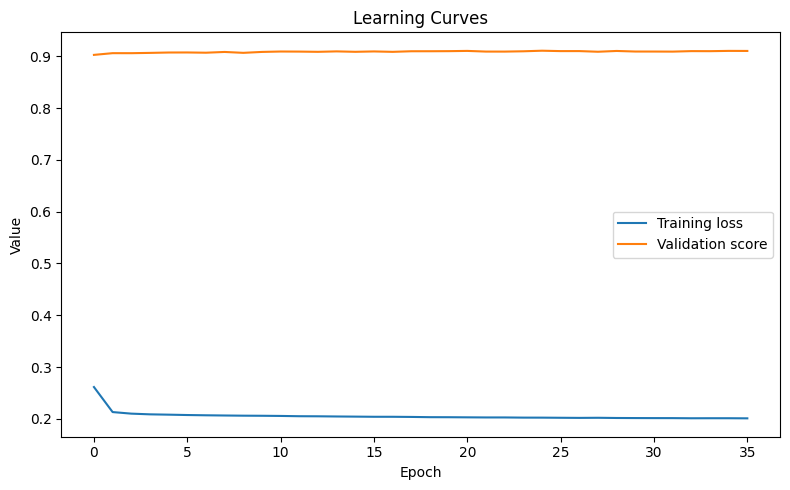

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(model.loss_curve_, label="Training loss")
plt.plot(model.validation_scores_, label="Validation score")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Learning Curves")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "learning_curves.png", dpi=150)
plt.show()

## Evaluate Model

The probability threshold is selected on the validation set by maximizing Dice score.

In [7]:
def dice_score(y_true, y_pred):
    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)
    denom = y_true.sum() + y_pred.sum()
    return 1.0 if denom == 0 else 2 * np.logical_and(y_true, y_pred).sum() / denom


def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return 0.0 if tn + fp == 0 else tn / (tn + fp)


def predict(model, scaler, df, threshold):
    X = scaler.transform(df[feature_columns])
    probabilities = model.predict_proba(X)[:, 1]
    return (probabilities >= threshold).astype(np.uint8)


X_val = scaler.transform(val_df[feature_columns])
y_val = val_df["wmh"].to_numpy()
val_probabilities = model.predict_proba(X_val)[:, 1]

best_threshold = 0.5
best_dice = -np.inf
for threshold in np.linspace(0.01, 0.99, 99):
    y_pred = (val_probabilities >= threshold).astype(np.uint8)
    current_dice = dice_score(y_val, y_pred)
    if current_dice > best_dice:
        best_dice = current_dice
        best_threshold = threshold

print(f"Best validation threshold: {best_threshold:.2f} | Dice: {best_dice:.4f}")

Best validation threshold: 0.97 | Dice: 0.4642


## Metrics And Confusion Matrices

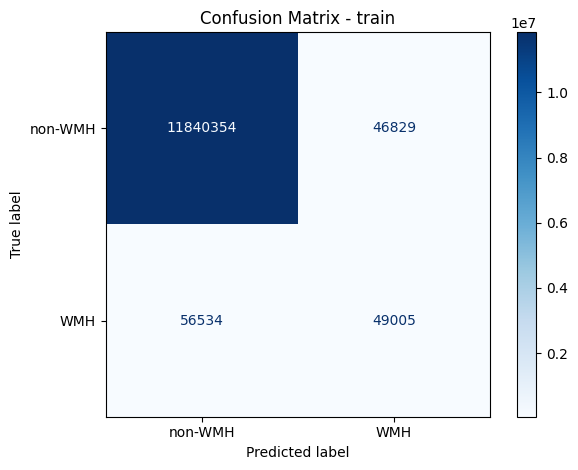

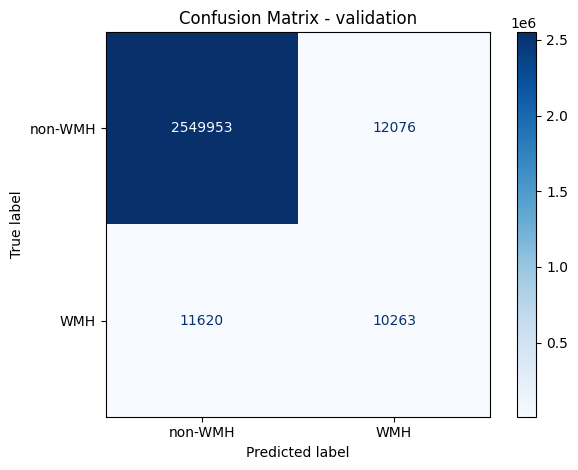

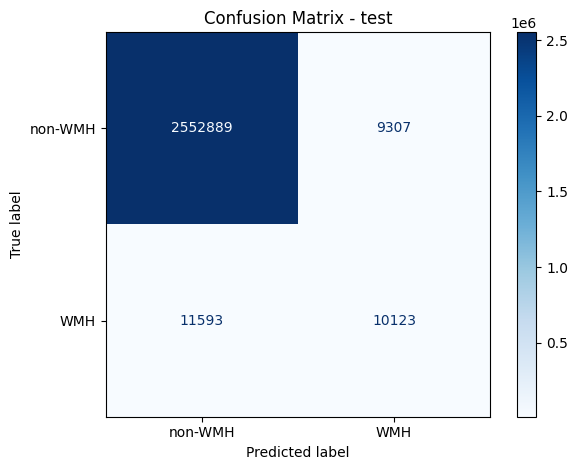

,set,threshold,accuracy,precision,recall,specificity,f1,dice
0,train,0.97,0.991381,0.511353,0.464331,0.996061,0.486709,0.486709
1,validation,0.97,0.990829,0.459421,0.468994,0.995287,0.464158,0.464158
2,test,0.97,0.991911,0.520998,0.466154,0.996368,0.492053,0.492053


In [8]:
results = []
sets = {"train": train_df, "validation": val_df, "test": test_df}

for name, set_df in sets.items():
    y_true = set_df["wmh"].to_numpy()
    y_pred = predict(model, scaler, set_df, best_threshold)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    results.append(
        {
            "set": name,
            "threshold": best_threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "specificity": specificity_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "dice": dice_score(y_true, y_pred),
        }
    )

    ConfusionMatrixDisplay(cm, display_labels=["non-WMH", "WMH"]).plot(
        values_format="d",
        cmap="Blues",
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.savefig(output_dir / f"confusion_matrix_{name}.png", dpi=150)
    plt.show()

results_df = pd.DataFrame(results)
results_df.to_csv(output_dir / "metrics.csv", index=False)
results_df